In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data collection from Kaggle

In [32]:
movie=pd.read_csv("tmdb_5000_movies.csv")

In [33]:
credit=pd.read_csv("tmdb_5000_credits.csv")

In [105]:
movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [35]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4803 non-null   int64 
 1   title     4803 non-null   object
 2   cast      4803 non-null   object
 3   crew      4803 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.2+ KB


In [36]:
movie.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [37]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4803 non-null   int64 
 1   title     4803 non-null   object
 2   cast      4803 non-null   object
 3   crew      4803 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.2+ KB


# Data Preprocessing

In [38]:
dataset = movie.merge(credit,on="title")
pd.set_option("display.max_columns",None) # for viewing max coloumns

In [39]:
dataset = dataset[["genres","id","overview","title","keywords","cast","crew"]]

In [40]:
dataset.shape

(4809, 7)

In [41]:
dataset.size

33663

In [42]:
dataset.ndim

2

In [43]:
dataset.isnull().sum()

genres      0
id          0
overview    3
title       0
keywords    0
cast        0
crew        0
dtype: int64

In [44]:
dataset.dropna(inplace=True)

In [45]:
dataset.duplicated().sum()

np.int64(0)

In [46]:
import ast # use for removing string on list " ' [ example ] ' "

def convert(obj):
    l = []
    for i in ast.literal_eval(obj):
        l.append(i["name"])
    return l

In [47]:
dataset["genres"] = dataset["genres"].apply(convert)

In [48]:
dataset["keywords"] = dataset["keywords"].apply(convert)

In [49]:
def convert2(obj):
    l2 = []
    counter=0
    for i in ast.literal_eval(obj):
        if counter != 0:
            l2.append(i["name"])
            counter+=1
        else:
            break

    return l2

In [50]:
dataset["cast"] = dataset["cast"].apply(convert)

In [51]:
def director(obj):
    l3 = []
    for i in ast.literal_eval(obj):
        if i["job"] == "Director":
            l3.append(i["name"])
            break

    return l3

In [52]:
dataset["crew"] = dataset["crew"].apply(director)

In [53]:
dataset["overview"] = dataset["overview"].apply(lambda x:x.split())

In [54]:
dataset["genres"] = dataset["genres"].apply(lambda x:[i.replace(" ","") for i in x])
dataset["keywords"] = dataset["keywords"].apply(lambda x:[i.replace(" ","") for i in x])
dataset["cast"] = dataset["cast"].apply(lambda x:[i.replace(" ","") for i in x])
dataset["crew"] = dataset["crew"].apply(lambda x:[i.replace(" ","") for i in x])

In [55]:
dataset["tags"] = dataset["overview"] + dataset["genres"] + dataset["keywords"] + dataset["cast"] + dataset["crew"]

In [56]:
dataset = dataset[["title","tags","id"]]

In [57]:
dataset["tags"] = dataset["tags"].apply(lambda x:" ".join(x))

In [58]:
dataset["tags"] = dataset["tags"].apply(lambda x:x.lower())

In [59]:
import nltk 
import re # remove , . ; -

In [60]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [61]:
def stem(text):
    y=[]
    text = re.sub(r"[^a-zA-Z\s]","",text)
    for i in text.split():
        y.append(ps.stem(i))
    return " ".join(y)

In [62]:
dataset["tags"] = dataset["tags"].apply(stem)

In [63]:
from sklearn.feature_extraction.text import CountVectorizer

In [64]:
cv = CountVectorizer(max_features=5000,stop_words="english")

In [65]:
vector = cv.fit_transform(dataset["tags"]).toarray()

# Exploratory Data Analysis

In [74]:
dataset.head()

,title,tags,id
0,Avatar,in the nd centuri a parapleg marin is dispatch...,19995
1,Pirates of the Caribbean: At World's End,captain barbossa long believ to be dead ha com...,285
2,Spectre,a cryptic messag from bond past send him on a ...,206647
3,The Dark Knight Rises,follow the death of district attorney harvey d...,49026
4,John Carter,john carter is a warweari former militari capt...,49529


In [75]:
dataset.tail()

,title,tags,id
4804,El Mariachi,el mariachi just want to play hi guitar and ca...,9367
4805,Newlyweds,a newlyw coupl honeymoon is upend by the arriv...,72766
4806,"Signed, Sealed, Delivered",sign seal deliv introduc a dedic quartet of ci...,231617
4807,Shanghai Calling,when ambiti new york attorney sam is sent to s...,126186
4808,My Date with Drew,ever sinc the second grade when he first saw h...,25975


In [76]:
dataset.describe()

,id
count,4806.000000
mean,56922.559509
std,88309.447559
min,5.000000
25%,9009.750000
50%,14615.500000
75%,58476.750000
max,447027.000000


In [77]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4806 entries, 0 to 4808
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   4806 non-null   object
 1   tags    4806 non-null   object
 2   id      4806 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 150.2+ KB


In [ ]:
sns.histplot(x="age",hue="stroke",data=dataset)
plt.title("Age vs Stroke")
plt.show()

In [79]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color="white")

### most repeated word in title

In [87]:
title_wc = wc.generate(dataset["title"].str.cat(sep=" "))

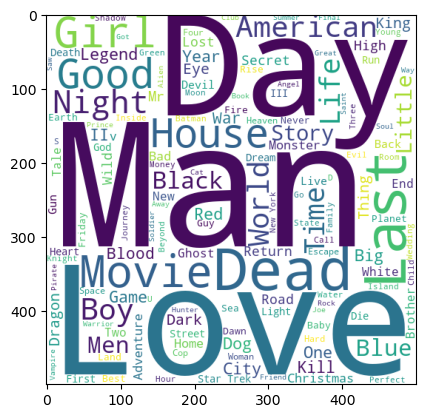

In [88]:
plt.imshow(title_wc)

### most repeated word in tags

In [90]:
tags_wc = wc.generate(dataset["tags"].str.cat(sep=" "))

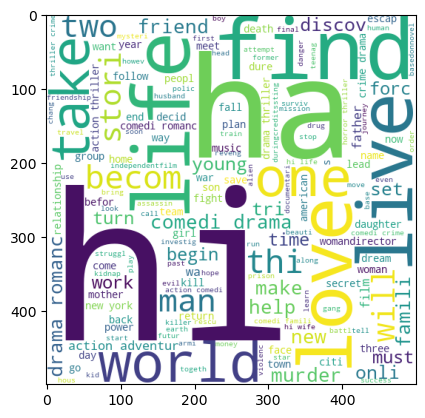

In [91]:
plt.imshow(tags_wc)

### top 25 tags keywords

In [97]:
top_tags = []
for msg in dataset["tags"].tolist():
    for word in msg.split():
        top_tags.append(word)

<Axes: xlabel='1', ylabel='0'>

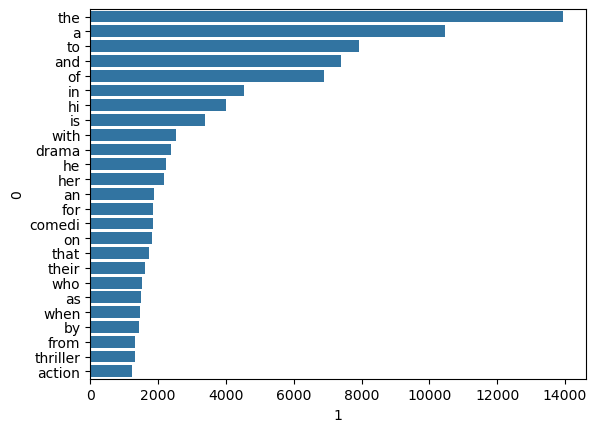

In [100]:
from collections import Counter
tt = pd.DataFrame(Counter(top_tags).most_common(25))
sns.barplot(x=tt[1], y=tt[0])

# Model selection and Training

In [66]:
from sklearn.metrics.pairwise import cosine_similarity

In [67]:
simi = cosine_similarity(vector)

In [68]:
def reco(movie):
    index = dataset[dataset["title"] == movie].index[0]
    distance = simi[index]
    movie_list = sorted(list(enumerate(distance)),reverse=True,key=lambda x:x[1])[1:11]

    for i in movie_list:
        print(dataset.iloc[i[0]].title)

# Files to download

In [70]:
import pickle
pickle.dump(dataset,open("movie predicter.pkl","wb"))

In [71]:
pickle.dump(simi,open("similarity.pkl","wb"))